In [31]:
%reload_ext autoreload
%autoreload 2

import PyUltraLight2 as PyUL

In [32]:
config = PyUL.Config()
config.FromFile("./BH1.uldm")

In [33]:
config.Saving

{'Loc': './', 'Flags': 'Minimum', 'Format': 'npy', 'Number': -1}

In [34]:
def ImaginaryPotential1(x,y,z):
    import numpy as np
    return 700*1j*np.exp(25*(-x*x - y*y - z*z))

In [35]:
config.Time["TimeDuration"] = 0.02

In [36]:
config.ADVANCED["ExtPhi"] = ImaginaryPotential1

In [37]:
config.ADVANCED["ExtPhi"]

<function __main__.ImaginaryPotential1(x, y, z)>

In [38]:
config.Space["Resolution"] = 128

In [39]:
config.uldm["Solitons"]

{'Condition': [[10, [0, 0, 0], [0, 0, 0], 0]],
 'Embedded': [],
 'MassUnits': '',
 'PositionUnits': '',
 'VelocityUnits': ''}

In [40]:
config.Saving["Number"] = 200

In [41]:
config.BlackHole["MatterParticles"]["Condition"] = [[1, [0,1,0], [0.2,0,0]]]

config.BlackHole

{'MatterParticles': {'Condition': [[1, [0, 1, 0], [0.2, 0, 0]]],
  'MassUnits': '',
  'PositionUnits': '',
  'VelocityUnits': '',
  'PlummerRadius': ''},
 'FieldSmoothing': 'Auto'}

In [42]:
loc = PyUL.Evolve(config,CenterCalc = True)

PyUL2   Init: Setting COM Evaluation to True.
PyUL2   Init: Adding new config attribute: CenterCalc = True
PyUL2    Sys: Starting RUN at ./Simulations/M1_L1_T0.02@128_20260526_214507!
PyUL2.40.3: (c) 2020 - 2024 Yourong F. Wang and collaborators. 
Auckland Cosmology

April 24 2026, "New Horizons."
Original PyUltraLight Team:
Edwards, F., Kendall, E., Hotchkiss, S. & Easther, R.
arxiv.org/abs/1807.04037
PyUL2    FFT: Using 10 CPU Threads for FFT.
PyUL2     IO: Copied Current Config to ./Simulations/M1_L1_T0.02@128_20260526_214507
PyUL2     IO: Data to save:
Energy 1Density NBody 1GravF
PyUL2  NBody: Using Linear Interpolation for gravity.
PyUL2    FFT: Simulation grid resolution is 128^3.
==========================Consistency=================================
Particle gravity  ON.
ULDM self-gravity  ON.
NBody response to ULDM  ON.
==========================Stopping Conditions=================================
PyUL2     SP: There is external potential!
PyUL2   Init: Loaded standard soliton

In [43]:
import numpy as np

In [44]:
MData = np.load(f"./{loc}/Outputs/masseslist.npy")

Text(0, 0.5, 'ULDM Mass in Box')

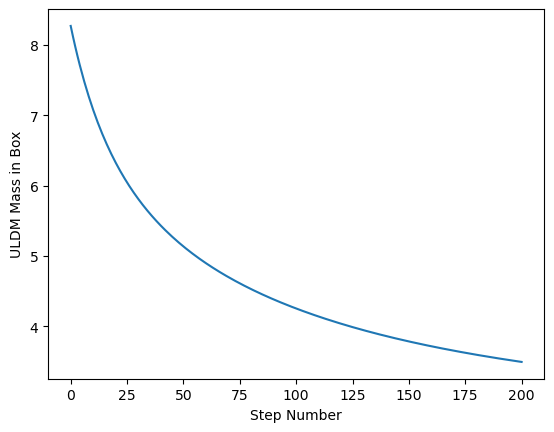

In [45]:
import matplotlib.pyplot as plt

plt.plot(MData)
plt.xlabel("Step Number")
plt.ylabel("ULDM Mass in Box")

In [ ]:
from PyUltraLight2.Utils.IO import Data

data = Data(f"./{loc}")

In [ ]:
Time = data.Tp

In [ ]:
Density = data.Loaded["1Density"]

plt.figure()
for i in range(data.EndNum):
    color = plt.cm.Spectral(i/data.EndNum)

    if i % 5 ==0:
        plt.plot(data.xAr, Density[i], color = color, label = f"Sim Time @ T = {data.Tp[i]:.3f}")
    else:
        plt.plot(data.xAr, Density[i], color = color)
    
plt.ylabel("Rho")
plt.xlabel("x")


In [ ]:
plt.plot(Time,data.nbody_S[:,0], label = "Coord 0")
plt.plot(Time,data.nbody_S[:,1], label = "Coord 1")
plt.plot(Time,data.nbody_S[:,2], label = "Coord 2")
plt.legend()

In [ ]:
Data2 = data.Loaded['1GravF']

plt.figure()
for i in range(data.EndNum):
    color = plt.cm.Spectral(i/data.EndNum)

    if i % 5 ==0:
        plt.plot(data.xAr, Data2[i], color = color, label = f"Sim Time @ T = {data.Tp[i]:.3f}")
    else:
        plt.plot(data.xAr, Data2[i], color = color)
    
plt.ylabel("Phi")
plt.xlabel("x")


In [ ]:
plt.imshow()